In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
books_df = pd.DataFrame({
    "book_id": [1, 2, 3, 4],
    "title": [
        "AI Agents for Developers",
        "Autonomous Systems in Practice",
        "LLM Agents Explained",
        "Building Multi-Agent AI"
    ],
    "format": ["ebook", "paperback", "ebook", "hardcover"],
    "list_price": [19.99, 29.99, 17.99, 39.99],
    "royalty_rate": [0.70, 0.60, 0.70, 0.55],
    "avg_KENP_pages": [420, 0, 380, 0]
})


In [3]:
dates = pd.date_range(start="2025-01-01", end="2025-03-31")

sales_df = pd.DataFrame({
    "date": np.random.choice(dates, 500),
    "book_id": np.random.choice(books_df.book_id, 500),
    "platform": np.random.choice(
        ["Amazon", "Barnes & Noble", "Apple Books"],
        500,
        p=[0.65, 0.20, 0.15]
    ),
    "units_sold": np.random.poisson(2, 500),
    "KENP_read": np.random.randint(0, 500, 500),
    "country": np.random.choice(
        ["US", "UK", "CA", "AU", "DE"],
        500,
        p=[0.5, 0.2, 0.1, 0.1, 0.1]
    )
})


In [4]:
marketing_df = pd.DataFrame({
    "campaign_id": range(1, 11),
    "platform": np.random.choice(
        ["Amazon Ads", "Facebook Ads", "Google Ads"],
        10
    ),
    "ad_spend": np.random.uniform(300, 2500, 10),
    "clicks": np.random.randint(500, 5000, 10),
    "conversions": np.random.randint(20, 400, 10)
})

marketing_df["cost_per_click"] = marketing_df["ad_spend"] / marketing_df["clicks"]
marketing_df["conversion_rate"] = marketing_df["conversions"] / marketing_df["clicks"]


In [5]:
costs_df = pd.DataFrame({
    "book_id": [1, 2, 3, 4],
    "editing_cost": [1200, 1800, 1000, 2200],
    "cover_design_cost": [600, 750, 500, 900],
    "formatting_cost": [300, 450, 300, 500],
    "fixed_marketing_cost": [1500, 2000, 1300, 2500]
})

costs_df["total_fixed_cost"] = costs_df.iloc[:, 1:].sum(axis=1)


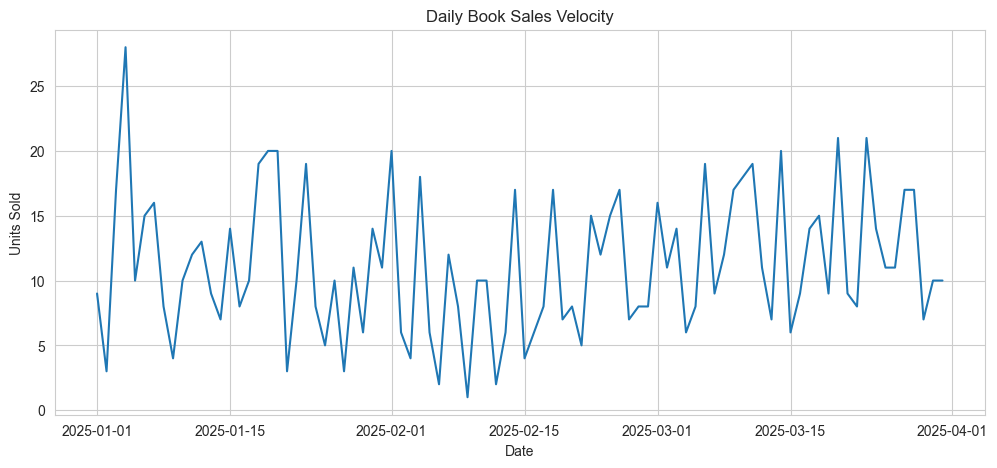

In [6]:
daily_sales = (
    sales_df
    .groupby("date")["units_sold"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,5))
plt.plot(daily_sales.date, daily_sales.units_sold)
plt.title("Daily Book Sales Velocity")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()


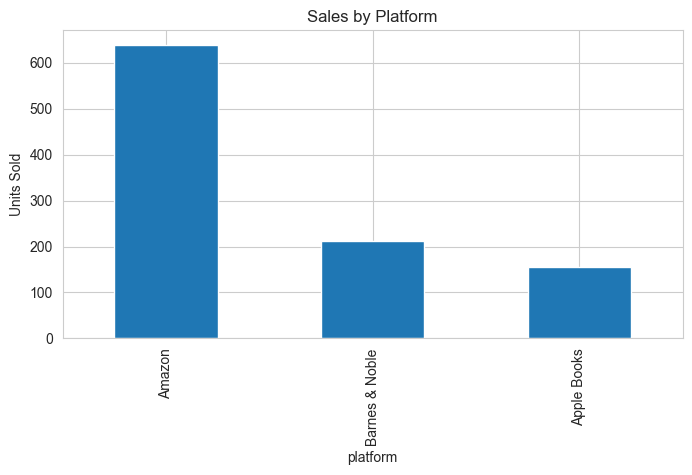

In [7]:
platform_sales = (
    sales_df
    .groupby("platform")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)

platform_sales.plot(kind="bar", figsize=(8,4), title="Sales by Platform")
plt.ylabel("Units Sold")
plt.show()


In [8]:
kenp_summary = (
    sales_df
    .groupby("book_id")["KENP_read"]
    .sum()
    .reset_index()
    .merge(books_df[["book_id", "title"]], on="book_id")
)

kenp_summary.sort_values("KENP_read", ascending=False)


,book_id,KENP_read,title
0,1,31689,AI Agents for Developers
3,4,31401,Building Multi-Agent AI
2,3,29778,LLM Agents Explained
1,2,29776,Autonomous Systems in Practice


In [9]:
marketing_df["estimated_revenue"] = marketing_df["conversions"] * 18.99
marketing_df["ROI"] = (
    marketing_df["estimated_revenue"] - marketing_df["ad_spend"]
) / marketing_df["ad_spend"]

marketing_df[["platform", "ad_spend", "estimated_revenue", "ROI"]]


,platform,ad_spend,estimated_revenue,ROI
0,Google Ads,1923.778192,7520.04,2.908995
1,Facebook Ads,2127.245278,2392.74,0.124807
2,Amazon Ads,1481.077641,4329.72,1.923358
3,Amazon Ads,1441.577204,6665.49,3.623748
4,Facebook Ads,364.517007,4576.59,11.555217
5,Google Ads,872.674087,1652.13,0.893181
6,Amazon Ads,1847.459481,1443.24,-0.218797
7,Amazon Ads,1084.118211,5165.28,3.764499
8,Google Ads,950.463682,3873.96,3.075863
9,Facebook Ads,1401.874464,5279.22,2.765829


In [10]:
sales_with_books = sales_df.merge(books_df, on="book_id")

sales_with_books["gross_revenue"] = (
    sales_with_books["units_sold"] *
    sales_with_books["list_price"] *
    sales_with_books["royalty_rate"]
)

profit_summary = (
    sales_with_books
    .groupby("book_id")["gross_revenue"]
    .sum()
    .reset_index()
    .merge(costs_df[["book_id", "total_fixed_cost"]], on="book_id")
)

profit_summary["net_profit"] = (
    profit_summary["gross_revenue"] - profit_summary["total_fixed_cost"]
)

profit_summary.merge(books_df[["book_id", "title"]], on="book_id")


,book_id,gross_revenue,total_fixed_cost,net_profit,title
0,1,3778.110,3600,178.110,AI Agents for Developers
1,2,4336.554,5000,-663.446,Autonomous Systems in Practice
2,3,3022.320,3100,-77.680,LLM Agents Explained
3,4,5630.592,6100,-469.408,Building Multi-Agent AI


In [11]:
sales_with_books = sales_df.merge(books_df, on="book_id")

sales_with_books["gross_revenue"] = (
    sales_with_books["units_sold"] *
    sales_with_books["list_price"] *
    sales_with_books["royalty_rate"]
)

profit_summary = (
    sales_with_books
    .groupby("book_id")["gross_revenue"]
    .sum()
    .reset_index()
    .merge(costs_df[["book_id", "total_fixed_cost"]], on="book_id")
)

profit_summary["net_profit"] = (
    profit_summary["gross_revenue"] - profit_summary["total_fixed_cost"]
)

profit_summary.merge(books_df[["book_id", "title"]], on="book_id")


,book_id,gross_revenue,total_fixed_cost,net_profit,title
0,1,3778.110,3600,178.110,AI Agents for Developers
1,2,4336.554,5000,-663.446,Autonomous Systems in Practice
2,3,3022.320,3100,-77.680,LLM Agents Explained
3,4,5630.592,6100,-469.408,Building Multi-Agent AI


In [12]:
sales_df["month"] = sales_df["date"].dt.to_period("M")

monthly_sales = (
    sales_df
    .groupby("month")["units_sold"]
    .sum()
    .reset_index()
)

monthly_sales


,month,units_sold
0,2025-01,352
1,2025-02,259
2,2025-03,396
